**A/B Test Analysis: Impact of a 50% Discount Message on Subscription Conversion**


**Business Context**

The goal of this experiment was to evaluate whether highlighting a 50% discount would increase subscription purchases.
Group A was shown the standard subscription offer priced at $4.99.
Group B was shown the same offer with an additional message indicating a 50% discount.
The primary metric for evaluation was Install-to-Payment Conversion Rate.


**Import Libraries**

This section imports the libraries required for data manipulation, statistical testing, and visualization.

In [ ]:
import pandas as pd
import numpy as np

from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

**Load and Explore Data**

The dataset contains user-level information, including experiment group assignment, event timestamp, and conversion outcome.

In [ ]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv('ab_test_data.csv')

Saving ab_test_data.csv to ab_test_data.csv


In [ ]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     19998 non-null  object
 1   timestamp   19998 non-null  object
 2   test_group  19998 non-null  object
 3   conversion  19998 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 625.1+ KB


,conversion
count,19998.000000
mean,0.075008
std,0.263410
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


**Data Overview**

First,  examine the size of each experimental group and calculate the primary business metric - conversion rate.

In [ ]:
results = df.groupby('test_group').agg(
    users=('user_id', 'count'),
    conversions=('conversion', 'sum'),
    conversion_rate=('conversion', 'mean')
)

results['conversion_rate'] = results['conversion_rate'] * 100

results

,users,conversions,conversion_rate
test_group,,,
a,10013,611,6.102067
b,9985,889,8.903355


**Experiment Duration**
To ensure the experiment ran for a sufficient period, calculate the test duration.

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [ ]:
start_date = df['timestamp'].min()
end_date = df['timestamp'].max()

duration = (end_date - start_date).days

print('Start:', start_date)
print('End:', end_date)
print('Duration:', duration, 'days')

Start: 2023-07-03 01:42:34.033708
End: 2023-07-25 01:41:19.152664
Duration: 21 days


The experiment ran from July 3, 2023 to July 25, 2023 and lasted 21 days.

**Statistical Hypothesis Testing**

**Hypotheses**

H0: Conversion rates are equal in groups A and B.

H1: Conversion rates differ between groups A and B.

To compare two conversion rates, a Two-Proportion Z-Test was used.

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

success = [611, 889]
nobs = [10013, 9985]

z_stat, p_value = proportions_ztest(success, nobs)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: -7.519675939906207
P-value: 5.491217728445103e-14


In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

Reject H0


**Statistical Results**

The obtained p-value is significantly below the significance threshold (α = 0.05).

Therefore, the null hypothesis is rejected and the observed difference between groups is statistically significant.

**Conversion Rate Comparison**

The chart below compares conversion rates between the two experimental groups together with 95% confidence intervals.

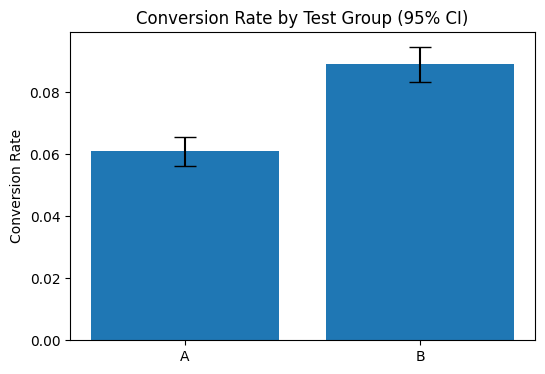

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

groups = ['A', 'B']
conversion_rates = [611 / 10013, 889 / 9985]
sample_sizes = [10013, 9985]

ci = []

for p, n in zip(conversion_rates, sample_sizes):
    se = np.sqrt(p * (1 - p) / n)
    ci.append(1.96 * se)

plt.figure(figsize=(6, 4))

plt.bar(
    groups,
    conversion_rates,
    yerr=ci,
    capsize=8
)

plt.ylabel('Conversion Rate')
plt.title('Conversion Rate by Test Group (95% CI)')

plt.show()

Group B achieved a higher conversion rate (8.90%) compared to Group A (6.10%).

The confidence intervals show a clear separation between the groups, supporting the conclusion that the improvement is statistically significant.

**Conversion Trend Over Time**

To assess the stability of the experiment, daily conversion rates were calculated for each group throughout the test period.

In [ ]:
df['date'] = df['timestamp'].dt.date

daily_conversion = (
    df.groupby(['date', 'test_group'])['conversion']
      .mean()
      .reset_index()
)

daily_conversion.head()

,date,test_group,conversion
0,2023-07-03,a,0.050971
1,2023-07-03,b,0.087640
2,2023-07-04,a,0.065022
3,2023-07-04,b,0.081858
4,2023-07-05,a,0.064220


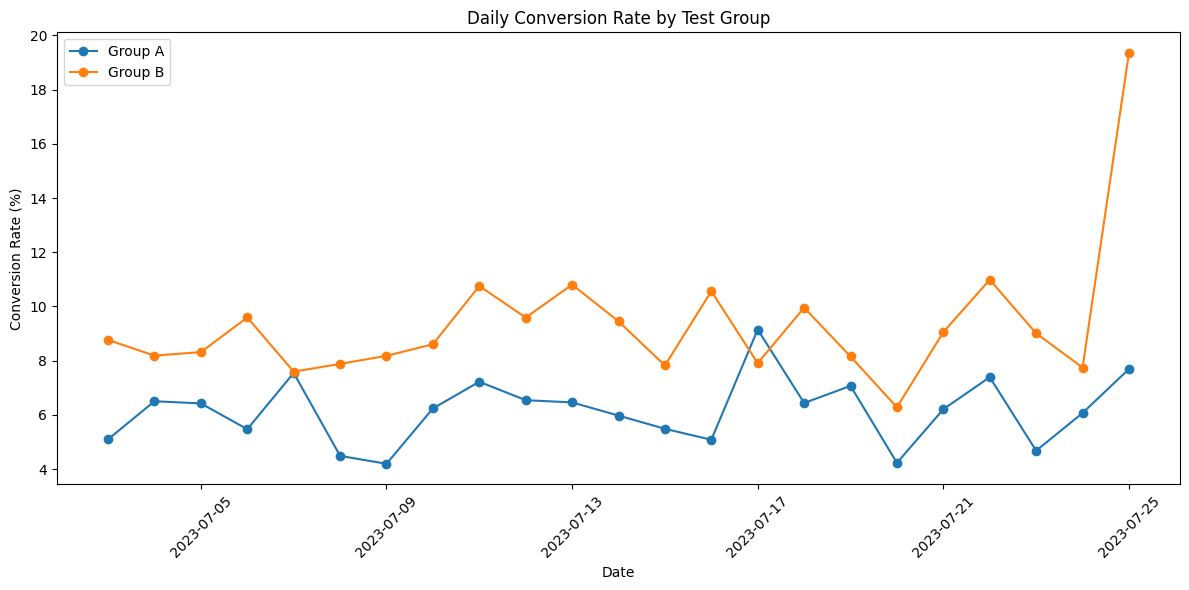

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for group in ['a', 'b']:
    data = daily_conversion[daily_conversion['test_group'] == group]

    plt.plot(
        data['date'],
        data['conversion'] * 100,
        marker='o',
        label=f'Group {group.upper()}'
    )

plt.title('Daily Conversion Rate by Test Group')
plt.xlabel('Date')
plt.ylabel('Conversion Rate (%)')
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Although daily conversion rates fluctuate, Group B consistently outperforms Group A during most of the experiment.

This indicates that the observed uplift is stable over time rather than being driven by a short-term anomaly.

**Conclusion**

The goal of this A/B test was to evaluate whether highlighting a 50% discount would increase subscription purchases.

The results showed that Group B outperformed Group A:

* Conversion Rate A: 6.10%
* Conversion Rate B: 8.90%

A Two-Proportion Z-Test was conducted to determine whether the observed difference was statistically significant. The test returned a p-value of 5.49 × 10⁻¹⁴, which is well below the significance level of 0.05.

Therefore, the null hypothesis was rejected, indicating that the difference in conversion rates between the two groups is statistically significant.

Based on the results of the experiment, Variant B should be recommended for implementation, as the discount message had a positive impact on subscription conversion.
